# What do ODE coordinates mean?

Interpretability notebook for ODE coefficients. This notebook focuses on energy attribution,
mode grouping, SSP (roll/streak/wave) diagnostics, nonlinear transfers, and local linear meaning.


## 1. Setup

In [21]:
using LinearAlgebra, Statistics, SparseArrays
using DataFrames, Plots

using CloudAtlas

α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,1,3                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
normalize = true                    # Normalize the basis set or not?

base_model = ODEModel(α, γ, J, K, L, H, normalize=normalize)  # Construct ODE model by Galerkin projection 

@show m = length(model)             # dimension of ODE model

J,K,L = 2,4,7                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
model = ODEModel(α, γ, J, K, L, H, normalize=normalize)  # Construct ODE model by Galerkin projection

# Choose a solution xstar (load from file or compute elsewhere)
# xstar = readdlm("path/to/eqb.asc")[:, 1]
# xstar = xstar[1:m]
# For a placeholder, use zeros:
xstar = zeros(m)


J,K,L,m == 1,1,3,17
(2J+1)(2K+1)(2L+1) + 1 == 64
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 
m = length(model) = 17
J,K,L,m == 2,4,7,169
(2J+1)(2K+1)(2L+1) + 1 == 676
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 


17-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [22]:
xguess = fill(Float64,0)

@show normalize
if !normalize
    xguess =  [0.105, -0.0539, 0.388, -0.0172, -0.0133, 0.0113, -0.00706, 0.0240, -0.0344, 
            -0.00868, -0.01264, -0.0234, -0.0320, -0.0180, -0.00464, 0.0106, 0.0235]
else
    xguess = [0.117, -0.0402, 0.201, -0.00779, -0.0158, 0.00719, -0.00551, 0.0126, -0.0281,
                  -0.00619, -0.0102, -0.0121, -0.0144, -0.0222, -0.00386, 0.01876, 0.0229]
end
xguess = changebasis(xguess, base_model.ijkl, model.ijkl) # change basis if needed

R = 200.0
f = x -> model.f(x,R)    # define function  f(x) = model.f(x,R) for fixed R
Df = x -> model.Df(x,R)  # define function Df(x) = model.Df(x,R) for fixed R

hookparams = SearchParams(ftol=1e-08, xtol=1e-12, Nnewton=30,Nhook=8,verbosity=0)
@time xsoln, found = hookstepsolve(f, Df, xguess)

@show norm(f(xsoln))/norm(xsoln)
@show norm(xsoln)
@show found;

xstar = xsoln

normalize = true
  0.385013 seconds (93.78 k allocations: 31.603 MiB, 6.76% gc time, 79.15% compilation time)
norm(f(xsoln)) / norm(xsoln) = 2.732633222451153e-14
norm(xsoln) = 0.23532571275454922
found = true


169-element Vector{Float64}:
  0.11387316330839814
 -0.03238730019510102
  0.0067707880368614885
  0.0009208013446538205
  0.19515073894073243
  0.0020379346968473276
  0.0065180319491995285
 -0.005418198163434817
 -0.01579126824205602
  0.005070289338098907
  ⋮
  0.0017180993202057877
  0.0003065150833489312
 -0.00038837794023362704
  0.0006715046934173824
 -0.00010725573375952351
 -0.00037286887411220514
 -0.0009674790751514369
 -0.000882751254882291
 -0.00146544996660955

## 2. Index map: coefficient to (kx, kz, component, wall shape, parity)

Build a mode table with one row per coefficient. This powers filtering, grouping,
and plotting in the rest of the notebook.


In [23]:
function basis_component_tag(psi)
    u_on = psi.u[1].coeff != 0
    v_on = psi.u[2].coeff != 0
    w_on = psi.u[3].coeff != 0
    if u_on && !v_on && !w_on
        return "u"
    elseif !u_on && v_on && !w_on
        return "v"
    elseif !u_on && !v_on && w_on
        return "w"
    elseif u_on && v_on && !w_on
        return "uv"
    elseif u_on && !v_on && w_on
        return "uw"
    elseif !u_on && v_on && w_on
        return "vw"
    else
        return "uvw"
    end
end

function basis_parity_tag(psi)
    if psi.u[1].coeff != 0
        ppar = psi.u[1].pparity
    elseif psi.u[2].coeff != 0
        ppar = psi.u[2].pparity
    else
        ppar = psi.u[3].pparity
    end
    if ppar == -1
        return "even"
    elseif ppar == 1
        return "odd"
    else
        return "mixed"
    end
end

function index_map(model)
    ijkl = model.ijkl
    m = size(ijkl, 1)
    rows = Vector{NamedTuple}(undef, m)
    for n in 1:m
        i, j, k, l = ijkl[n, :]
        psi = model.Ψ[n]
        rows[n] = (
            n = n,
            i = i,
            j = j,
            k = k,
            l = l,
            kx = j,
            kz = k,
            component = basis_component_tag(psi),
            wall_family = (i in (1, 3, 5)) ? "Sprime" : "S",
            parity = basis_parity_tag(psi),
        )
    end
    DataFrame(rows)
end

mode_df = index_map(model)
# mode_df[1:10, :]
mode_df


Row,n,i,j,k,l,kx,kz,component,wall_family,parity
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,String,String,String
1,1,1,0,0,1,0,0,u,Sprime,even
2,2,1,0,0,3,0,0,u,Sprime,even
3,3,1,0,0,5,0,0,u,Sprime,even
4,4,1,0,0,7,0,0,u,Sprime,even
5,5,1,0,1,0,0,1,u,Sprime,odd
6,6,1,0,1,2,0,1,u,Sprime,odd
7,7,1,0,1,4,0,1,u,Sprime,odd
8,8,1,0,1,6,0,1,u,Sprime,odd
9,9,2,0,1,1,0,1,vw,S,odd


## 3. Energy decomposition

Compute total energy, per-coordinate contributions, and grouped energies. Then plot:

- top 30 coefficients by energy
- energy by k-shell (abs(kx) + abs(kz))
- heatmap of energy vs (kx, kz)


In [25]:
B = model.B
Bx = B * xstar
E_total = 0.5 * dot(xstar, Bx)

# Per-coordinate energy contribution that sums to E_total
mode_df.energy = 0.5 .* xstar .* Bx

# Group energy by (kx, kz, component, wall family)
energy_groups = combine(
    groupby(mode_df, [:kx, :kz, :component, :wall_family]),
    :energy => sum => :E
)

E_total, energy_groups[1:10, :]
# E_total, energy_groups


(0.031080919496100527, 10×5 DataFrame
 Row │ kx     kz     component  wall_family  E           
     │ Int64  Int64  String     String       Float64     
─────┼───────────────────────────────────────────────────
   1 │     0      0  u          Sprime       0.0101465
   2 │     0      1  u          Sprime       0.0189702
   3 │     0      1  vw         S            0.000216227
   4 │     0     -2  u          Sprime       0.000152532
   5 │     0     -2  vw         S            2.82864e-6
   6 │     0      3  u          Sprime       5.67024e-5
   7 │     0      3  vw         S            2.15885e-7
   8 │     0     -4  u          Sprime       1.42181e-7
   9 │     0     -4  vw         S            3.13833e-8
  10 │    -1      0  w          Sprime       0.000135829)

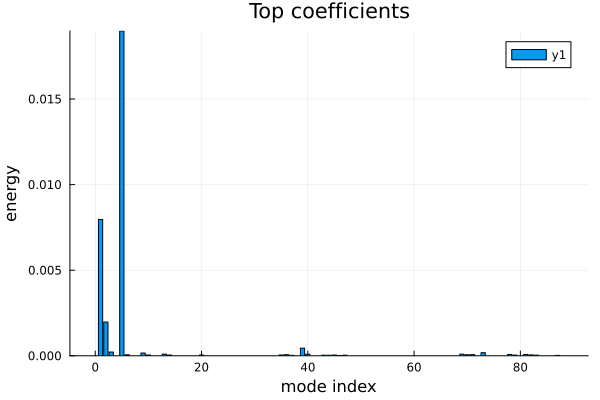

In [26]:
# Top-30 coefficients by energy
mode_sorted = sort(mode_df, :energy, rev=true)
top = mode_sorted[1:min(30, nrow(mode_sorted)), :]
bar(top.n, top.energy, xlabel="mode index", ylabel="energy", title="Top coefficients")


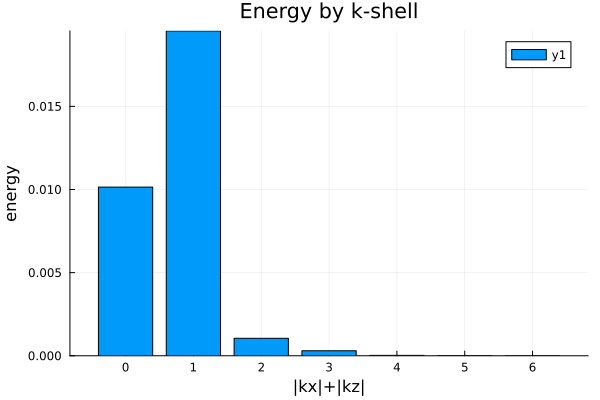

In [27]:
# Energy by k-shell: |kx| + |kz|
mode_df.k_shell = abs.(mode_df.kx) .+ abs.(mode_df.kz)
kshell = combine(groupby(mode_df, :k_shell), :energy => sum => :E)
kshell = sort(kshell, :k_shell)
bar(kshell.k_shell, kshell.E, xlabel="|kx|+|kz|", ylabel="energy", title="Energy by k-shell")


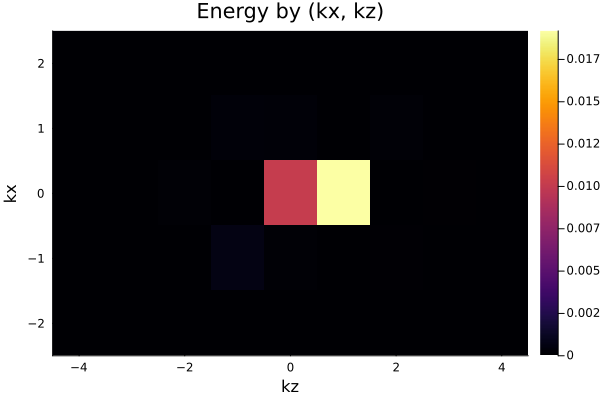

In [28]:
# Heatmap of energy vs (kx, kz)
kx_vals = sort(unique(mode_df.kx))
kz_vals = sort(unique(mode_df.kz))
Egrid = zeros(length(kx_vals), length(kz_vals))

for row in eachrow(mode_df)
    ix = findfirst(==(row.kx), kx_vals)
    iz = findfirst(==(row.kz), kz_vals)
    Egrid[ix, iz] += row.energy
end

heatmap(kz_vals, kx_vals, Egrid, xlabel="kz", ylabel="kx", title="Energy by (kx, kz)")


## 4. SSP lens (roll / streak / wave)

Define SSP groups and compute energy splits. For equilibria/TWs, this is just
a three-number breakdown. For trajectories, evaluate per snapshot and plot time series.


In [29]:
function ssp_group(row)
    if row.kx == 0 && row.component == "u"
        return "streak"
    elseif row.kx == 0 && (row.component == "v" || row.component == "w" || row.component == "vw")
        return "roll"
    elseif row.kx != 0
        return "wave"
    else
        return "other"
    end
end

mode_df.ssp = [ssp_group(row) for row in eachrow(mode_df)]
ssp_energy = combine(groupby(mode_df, :ssp), :energy => sum => :E)

ssp_energy


Row,ssp,E
,String,Float64
1,streak,0.0293261
2,roll,0.000219303
3,wave,0.00153551


## 5. Nonlinear transfer: who feeds who?

If you can compute the quadratic term N(x) or the full RHS f(x), then estimate
instantaneous power into each group.


In [30]:
function group_power(x, fx, B, idxs)
    xg = x[idxs]
    fg = fx[idxs]
    Bg = B[idxs, idxs]
    dot(xg, Bg * fg)
end

# Full RHS and nonlinear-only RHS
fx = model.f(xstar, Re)
fx_nl = model.Bfact \ model.N(xstar)

# Group powers
powers = Dict{String, Float64}()
for g in unique(mode_df.ssp)
    idxs = findall(mode_df.ssp .== g)
    powers[g] = group_power(xstar, fx, B, idxs)
end

powers


Dict{String, Float64} with 3 entries:
  "streak" => 0.001167
  "roll"   => 1.27759e-5
  "wave"   => 0.000142398

## 6. Local dynamical meaning

Compute the Jacobian at xstar and project eigenvectors onto SSP groups.
For large systems, switch to an Arnoldi method (e.g., Arpack.jl).


In [31]:
Df = model.Df(xstar, Re)
E = eigen(Df)

function group_energy_fraction(v, B, group_idxs)
    Bg = B[group_idxs, group_idxs]
    vg = v[group_idxs]
    Eg = real(dot(vg, Bg * vg))
    Etot = real(dot(v, B * v))
    Eg / Etot
end

# Example: group fractions for the most unstable eigenvector
idx_max = argmax(real(E.values))
v = E.vectors[:, idx_max]

fractions = Dict{String, Float64}()
for g in unique(mode_df.ssp)
    idxs = findall(mode_df.ssp .== g)
    fractions[g] = group_energy_fraction(v, B, idxs)
end

E.values[idx_max], fractions


(0.054644455563017086 - 0.010067879923722465im, Dict("streak" => 0.7052558059161912, "roll" => 0.03740116128087879, "wave" => 0.25734303280292986))

## 7. Optional: learned coordinates

If you have a dataset of solutions, compute PCA and map PCs into the same
(kx, kz) and SSP group diagnostics.


In [32]:
# Example (placeholder):
# X = hcat(sol1, sol2, sol3, ...)
# Xc = X .- mean(X, dims=2)
# U, S, Vt = svd(Xc; full=false)
# pc1 = U[:, 1]
# Project pc1 into the same group diagnostics as above.
